# 🎵 Music Features & Lyrics Analysis
**Student:** Betül Eken  34378

**Course:** DSA210 - Introduction to Data Science

---

### 🚀 Welcome to My Analysis
### 🚀 Introduction

Music is a complex form of expression shaped by both **acoustic properties** and **linguistic content**.  
While modern platforms such as Spotify quantify songs using numerical audio features (e.g., energy, valence, tempo), lyrics reflect emotional and linguistic patterns that are harder to quantify using simple numerical representations.


This project explores the extent to which **musical features** and **basic lyrical characteristics** can explain or predict song-level attributes such as **popularity**, **emotional valence**, and **energy**.  
Rather than assuming strong predictive power, the analysis adopts an exploratory approach to evaluate **what can and cannot be inferred** from these features.

By combining audio data with NLP-based lyrical features, this study aims to understand the **limitations and strengths** of surface-level representations in music analysis.


### 🧩 Notebook Overview

This notebook follows a structured data science pipeline:

1. **📥 Data Loading**: Importing Spotify audio features and raw song lyrics.  
2. **🔗 Data Merging & Cleaning**: Creating a unified dataset of approximately **1,700 songs**.  
3. **📝 NLP Feature Engineering**: Extracting basic lyrical features such as word count and lexical diversity.  
4. **📊 Exploratory Analysis & Modeling**: Evaluating the predictive power of musical and lyrical features using statistical analysis and machine learning models.


## 1. 📥 Data Loading
We are using two distinct datasets for this project:
1.  **Spotify Tracks Dataset:** Contains numerical audio features (`energy`, `valence`, `tempo`, `loudness`).
2.  **Lyrics Dataset:** Contains the raw text of the songs (`lyrics`).

We will load them separately and preview their structure.

In [109]:
import pandas as pd

# Load the first dataset
df1 = pd.read_csv("https://raw.githubusercontent.com/betulbeken/DSA210--Song-lyrics-and-musical-features-analysis/refs/heads/main/dataset.csv")
display(df1.head())

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [110]:
import pandas as pd
import requests
from io import BytesIO
import zipfile

# 1. Download the zip file content
url_lyrics = "https://github.com/betulbeken/DSA210--Song-lyrics-and-musical-features-analysis/raw/main/spotify_songs.csv.zip"
response = requests.get(url_lyrics)

# 2. Open the specific CSV file inside the zip
with zipfile.ZipFile(BytesIO(response.content)) as z:
    # Use the specific filename 'spotify_songs.csv' (ignoring the __MACOSX one)
    with z.open("spotify_songs.csv") as f:
        df2 = pd.read_csv(f)

print("✅ Lyrics Data Loaded Successfully!")
display(df2.head())

✅ Lyrics Data Loaded Successfully!


,track_id,track_name,track_artist,lyrics,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,language
0,0017A6SJgTbfQVU2EtsPNo,Pangarap,Barbie's Cradle,Minsan pa Nang ako'y napalingon Hindi ko alam ...,41,1srJQ0njEQgd8w4XSqI4JQ,Trip,2001-01-01,Pinoy Classic Rock,37i9dQZF1DWYDQ8wBxd7xt,...,-10.068,1,0.0236,0.27900,0.01170,0.0887,0.566,97.091,235440,tl
1,004s3t0ONYlzxII9PLgU6z,I Feel Alive,Steady Rollin,"The trees, are singing in the wind The sky blu...",28,3z04Lb9Dsilqw68SHt6jLB,Love & Loss,2017-11-21,Hard Rock Workout,3YouF0u7waJnolytf9JCXf,...,-4.739,1,0.0442,0.01170,0.00994,0.3470,0.404,135.225,373512,en
2,00chLpzhgVjxs1zKC9UScL,Poison,Bell Biv DeVoe,"NA Yeah, Spyderman and Freeze in full effect U...",0,6oZ6brjB8x3GoeSYdwJdPc,Gold,2005-01-01,"Back in the day - R&B, New Jack Swing, Swingbe...",3a9y4eeCJRmG9p4YKfqYIx,...,-7.504,0,0.2160,0.00432,0.00723,0.4890,0.650,111.904,262467,en
3,00cqd6ZsSkLZqGMlQCR0Zo,Baby It's Cold Outside (feat. Christina Aguilera),CeeLo Green,I really can't stay Baby it's cold outside I'v...,41,3ssspRe42CXkhPxdc12xcp,CeeLo's Magic Moment,2012-10-29,Christmas Soul,6FZYc2BvF7tColxO8PBShV,...,-5.819,0,0.0341,0.68900,0.00000,0.0664,0.405,118.593,243067,en
4,00emjlCv9azBN0fzuuyLqy,Dumb Litty,KARD,Get up out of my business You don't keep me fr...,65,7h5X3xhh3peIK9Y0qI5hbK,KARD 2nd Digital Single ‘Dumb Litty’,2019-09-22,K-Party Dance Mix,37i9dQZF1DX4RDXswvP6Mj,...,-1.993,1,0.0409,0.03700,0.00000,0.1380,0.240,130.018,193160,en


## 2. 🔗 Data Merging
To analyze the relationship between sound and text, we must link these datasets.
We merge on **`track_name`** and **`artists`** to ensure we are matching the correct lyrics to the correct audio features.

In [111]:
# Merge the two DataFrames on 'track_name' and 'artists'
#'song names' refers to 'track_name' and 'artist names' refers to 'artists'

print("Columns of df1:", df1.columns)
print("Columns of df2:", df2.columns)

merged_df = pd.merge(df1, df2, left_on=['track_name', 'artists'], right_on=['track_name', 'track_artist'], how='inner')
display(merged_df.head())
display(merged_df.shape)

Columns of df1: Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')
Columns of df2: Index(['track_id', 'track_name', 'track_artist', 'lyrics', 'track_popularity',
       'track_album_id', 'track_album_name', 'track_album_release_date',
       'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre',
       'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'duration_ms', 'language'],
      dtype='object')


,Unnamed: 0,track_id_x,artists,album_name,track_name,popularity,duration_ms_x,explicit,danceability_x,energy_x,...,loudness_y,mode_y,speechiness_y,acousticness_y,instrumentalness_y,liveness_y,valence_y,tempo_y,duration_ms_y,language
0,7,1EzrEOXmMH3G43AXT1y7pA,Jason Mraz,We Sing. We Dance. We Steal Things.,I'm Yours,80,242946,False,0.703,0.444,...,-8.322,1,0.0468,0.595,0.000000,0.105,0.718,150.953,242187,en
1,7,1EzrEOXmMH3G43AXT1y7pA,Jason Mraz,We Sing. We Dance. We Steal Things.,I'm Yours,80,242946,False,0.703,0.444,...,-8.322,1,0.0468,0.595,0.000000,0.105,0.718,150.953,242187,en
2,20,3S0OXQeoh0w6AY8WQVckRW,Jason Mraz,We Sing. We Dance. We Steal Things.,I'm Yours,75,242946,False,0.703,0.444,...,-8.322,1,0.0468,0.595,0.000000,0.105,0.718,150.953,242187,en
3,20,3S0OXQeoh0w6AY8WQVckRW,Jason Mraz,We Sing. We Dance. We Steal Things.,I'm Yours,75,242946,False,0.703,0.444,...,-8.322,1,0.0468,0.595,0.000000,0.105,0.718,150.953,242187,en
4,82,3bHhUEOTIbezeZ856R0BX5,Eddie Vedder,Into The Wild (Music For The Motion Picture),Society,68,236306,False,0.561,0.327,...,-10.835,0,0.0327,0.902,0.000469,0.111,0.298,161.861,236307,en


(7058, 45)

### Removing duplicate rows from the merged DataFrame

In [112]:
print(f"Shape of merged_df before removing duplicates: {merged_df.shape}")
merged_df_no_duplicates = merged_df.drop_duplicates(subset=['track_name', 'artists']).reset_index(drop=True)
print(f"Shape of merged_df after removing duplicates: {merged_df_no_duplicates.shape}")
display(merged_df_no_duplicates.head())

Shape of merged_df before removing duplicates: (7058, 45)
Shape of merged_df after removing duplicates: (1833, 45)


,Unnamed: 0,track_id_x,artists,album_name,track_name,popularity,duration_ms_x,explicit,danceability_x,energy_x,...,loudness_y,mode_y,speechiness_y,acousticness_y,instrumentalness_y,liveness_y,valence_y,tempo_y,duration_ms_y,language
0,7,1EzrEOXmMH3G43AXT1y7pA,Jason Mraz,We Sing. We Dance. We Steal Things.,I'm Yours,80,242946,False,0.703,0.444,...,-8.322,1,0.0468,0.5950,0.000000,0.1050,0.7180,150.953,242187,en
1,82,3bHhUEOTIbezeZ856R0BX5,Eddie Vedder,Into The Wild (Music For The Motion Picture),Society,68,236306,False,0.561,0.327,...,-10.835,0,0.0327,0.9020,0.000469,0.1110,0.2980,161.861,236307,en
2,126,5rwq6R0Uq0BngM3rdmCeNg,Howie Day,Stop All the World Now (Special Edition),Collide - Acoustic Version,67,277000,False,0.582,0.253,...,-11.430,1,0.0259,0.8270,0.000029,0.0910,0.2940,90.184,277000,en
3,169,4E6cwWJWZw2zWf7VFbH7wf,Sara Bareilles,Little Voice,Love Song,73,258826,False,0.583,0.786,...,-3.142,0,0.0301,0.0208,0.000000,0.1880,0.5730,123.052,258827,en
4,194,7xLhousIHDxoGgeJNhO4Ye,A Great Big World,Is There Anybody Out There? - Track by Track C...,Say Something,57,233266,False,0.447,0.158,...,-8.822,1,0.0355,0.8570,0.000003,0.0913,0.0765,141.284,229400,en


## 3. 📝 NLP Feature Engineering
This is the core of our text analysis. We cannot simply count words, as that includes noise.
We define a function `clean_lyrics` that:
1.  **Lowercases** all text.
2.  **Removes Punctuation** (e.g., `[Chorus]`, commas).
3.  **Removes Stopwords:** Filters out common English words (e.g., "the", "a") to focus on content.

**New Features Created:**
* `clean_word_count`: Count of meaningful words.
* `lexical_diversity` (TTR): The ratio of **Unique Words / Total Words**. (Higher = More Complex).

In [113]:
import re
import nltk
from nltk.corpus import stopwords

# Download NLTK stopwords if not already downloaded
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')


In [114]:
def clean_lyrics(text):
    # Handle non-string inputs (e.g., NaN values)
    if not isinstance(text, str):
        return ""

    # 1. Lowercase text and remove punctuation/special characters
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text) # Remove anything that's not a letter or space

    # 2. Remove English STOPWORDS
    stop_words = set(stopwords.words('english'))
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return ' '.join(filtered_words)

In [115]:
# Apply the clean_lyrics function to the 'lyrics' column
merged_df_no_duplicates['cleaned_lyrics'] = merged_df_no_duplicates['lyrics'].apply(clean_lyrics)

display(merged_df_no_duplicates[['track_name', 'lyrics', 'cleaned_lyrics']].head())

,track_name,lyrics,cleaned_lyrics
0,I'm Yours,"Well, you done done me, and you bet I felt it ...",well done done bet felt tried chill youre hot ...
1,Society,Hmmm ooh hooo hooo It's a mystery to me We hav...,hmmm ooh hooo hooo mystery greed agreed think ...
2,Collide - Acoustic Version,The dawn is breaking A light shining through Y...,dawn breaking light shining youre barely wakin...
3,Love Song,Head under water And they tell me to breathe e...,head water tell breathe easy breathing gets ha...
4,Say Something,"Say something, I'm giving up on you I'll be th...",say something im giving ill one want anywhere ...


### Removing rows without lyrics

In [116]:
print(f"Shape of DataFrame before removing rows with no lyrics: {merged_df_no_duplicates.shape}")
merged_df_with_lyrics = merged_df_no_duplicates[merged_df_no_duplicates['cleaned_lyrics'] != ''].reset_index(drop=True)
print(f"Shape of DataFrame after removing rows with no lyrics: {merged_df_with_lyrics.shape}")
display(merged_df_with_lyrics.head())

Shape of DataFrame before removing rows with no lyrics: (1833, 46)
Shape of DataFrame after removing rows with no lyrics: (1807, 46)


,Unnamed: 0,track_id_x,artists,album_name,track_name,popularity,duration_ms_x,explicit,danceability_x,energy_x,...,mode_y,speechiness_y,acousticness_y,instrumentalness_y,liveness_y,valence_y,tempo_y,duration_ms_y,language,cleaned_lyrics
0,7,1EzrEOXmMH3G43AXT1y7pA,Jason Mraz,We Sing. We Dance. We Steal Things.,I'm Yours,80,242946,False,0.703,0.444,...,1,0.0468,0.5950,0.000000,0.1050,0.7180,150.953,242187,en,well done done bet felt tried chill youre hot ...
1,82,3bHhUEOTIbezeZ856R0BX5,Eddie Vedder,Into The Wild (Music For The Motion Picture),Society,68,236306,False,0.561,0.327,...,0,0.0327,0.9020,0.000469,0.1110,0.2980,161.861,236307,en,hmmm ooh hooo hooo mystery greed agreed think ...
2,126,5rwq6R0Uq0BngM3rdmCeNg,Howie Day,Stop All the World Now (Special Edition),Collide - Acoustic Version,67,277000,False,0.582,0.253,...,1,0.0259,0.8270,0.000029,0.0910,0.2940,90.184,277000,en,dawn breaking light shining youre barely wakin...
3,169,4E6cwWJWZw2zWf7VFbH7wf,Sara Bareilles,Little Voice,Love Song,73,258826,False,0.583,0.786,...,0,0.0301,0.0208,0.000000,0.1880,0.5730,123.052,258827,en,head water tell breathe easy breathing gets ha...
4,194,7xLhousIHDxoGgeJNhO4Ye,A Great Big World,Is There Anybody Out There? - Track by Track C...,Say Something,57,233266,False,0.447,0.158,...,1,0.0355,0.8570,0.000003,0.0913,0.0765,141.284,229400,en,say something im giving ill one want anywhere ...


### Creating new lyrical features and applying data quality filters

In [117]:
# Calculate clean_word_count: Count of meaningful words
merged_df_with_lyrics['clean_word_count'] = merged_df_with_lyrics['cleaned_lyrics'].apply(lambda x: len(x.split()) if x else 0)

# Calculate clean_unique_count: Count of unique meaningful words
merged_df_with_lyrics['clean_unique_count'] = merged_df_with_lyrics['cleaned_lyrics'].apply(lambda x: len(set(x.split())) if x else 0)

# Calculate lexical_diversity: clean_unique_count / clean_word_count
merged_df_with_lyrics['lexical_diversity'] = merged_df_with_lyrics.apply(
    lambda row: row['clean_unique_count'] / row['clean_word_count'] if row['clean_word_count'] > 0 else 0,
    axis=1
)

display(merged_df_with_lyrics[['track_name', 'cleaned_lyrics', 'clean_word_count', 'clean_unique_count', 'lexical_diversity']].head())

,track_name,cleaned_lyrics,clean_word_count,clean_unique_count,lexical_diversity
0,I'm Yours,well done done bet felt tried chill youre hot ...,474,130,0.274262
1,Society,hmmm ooh hooo hooo mystery greed agreed think ...,99,46,0.464646
2,Collide - Acoustic Version,dawn breaking light shining youre barely wakin...,93,54,0.580645
3,Love Song,head water tell breathe easy breathing gets ha...,208,84,0.403846
4,Say Something,say something im giving ill one want anywhere ...,144,31,0.215278


## 🧹 Data Quality Filtering
**Crucial Step:** We filter out songs that are:
* **Instrumental** (`instrumentalness > 0.5`): These tracks have no real lyrics, so analyzing them would add noise.
* **Too Short** (`clean_word_count < 10`): Songs with almost no words cannot provide a reliable lexical diversity score.

In [118]:
print(f"Shape before filtering for instrumentals and word count: {merged_df_with_lyrics.shape}")

# Filter out songs that are likely instrumentals (instrumentalness > 0.5)
# Using 'instrumentalness_x' assuming it's the relevant column from df1
filtered_df = merged_df_with_lyrics[merged_df_with_lyrics['instrumentalness_x'] <= 0.5]

# Filter out songs that have very few words (clean_word_count < 10)
filtered_df = filtered_df[filtered_df['clean_word_count'] >= 10].reset_index(drop=True)

print(f"Shape after filtering: {filtered_df.shape}")
display(filtered_df.head())

Shape before filtering for instrumentals and word count: (1807, 49)
Shape after filtering: (1720, 49)


,Unnamed: 0,track_id_x,artists,album_name,track_name,popularity,duration_ms_x,explicit,danceability_x,energy_x,...,instrumentalness_y,liveness_y,valence_y,tempo_y,duration_ms_y,language,cleaned_lyrics,clean_word_count,clean_unique_count,lexical_diversity
0,7,1EzrEOXmMH3G43AXT1y7pA,Jason Mraz,We Sing. We Dance. We Steal Things.,I'm Yours,80,242946,False,0.703,0.444,...,0.000000,0.1050,0.7180,150.953,242187,en,well done done bet felt tried chill youre hot ...,474,130,0.274262
1,82,3bHhUEOTIbezeZ856R0BX5,Eddie Vedder,Into The Wild (Music For The Motion Picture),Society,68,236306,False,0.561,0.327,...,0.000469,0.1110,0.2980,161.861,236307,en,hmmm ooh hooo hooo mystery greed agreed think ...,99,46,0.464646
2,126,5rwq6R0Uq0BngM3rdmCeNg,Howie Day,Stop All the World Now (Special Edition),Collide - Acoustic Version,67,277000,False,0.582,0.253,...,0.000029,0.0910,0.2940,90.184,277000,en,dawn breaking light shining youre barely wakin...,93,54,0.580645
3,169,4E6cwWJWZw2zWf7VFbH7wf,Sara Bareilles,Little Voice,Love Song,73,258826,False,0.583,0.786,...,0.000000,0.1880,0.5730,123.052,258827,en,head water tell breathe easy breathing gets ha...,208,84,0.403846
4,194,7xLhousIHDxoGgeJNhO4Ye,A Great Big World,Is There Anybody Out There? - Track by Track C...,Say Something,57,233266,False,0.447,0.158,...,0.000003,0.0913,0.0765,141.284,229400,en,say something im giving ill one want anywhere ...,144,31,0.215278


###📊 4- Exploratory Analysis & Modeling


### Model 1: Popularity Prediction Using Musical Features
### 🎯 Feature Selection and Train–Test Split

Musical (audio) features are used as input variables (X), and song popularity is used as the target variable (y).  
The dataset is split into training (80%) and test (20%) sets to evaluate model performance on unseen data.



---




In [119]:
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report
)
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

In [120]:
feature_columns = ['danceability_x', 'energy_x', 'key_x', 'loudness_x', 'mode_x', 'speechiness_x', 'acousticness_x', 'instrumentalness_x', 'liveness_x', 'valence_x', 'tempo_x']
X = filtered_df[feature_columns]
y = filtered_df['popularity']

In [121]:
# Split the data into training and testing sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### 📏 Baseline Model

A baseline model predicting the mean popularity is used as a reference point.  
Any machine learning model should perform better than this baseline to be considered useful.


In [122]:
baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_test)

mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
r2_baseline = r2_score(y_test, y_pred_baseline)

print(f"Baseline MAE: {mae_baseline:.2f}")
print(f"Baseline R2: {r2_baseline:.2f}")


Baseline MAE: 22.93
Baseline R2: -0.00


### 📊 Linear Regression Model

A Linear Regression model is trained to examine whether musical features can explain variations in song popularity.


In [123]:
# Initialize the Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

In [124]:
# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Absolute Error (MAE): 22.65
Mean Squared Error (MSE): 811.63
R-squared (R2): 0.03


The model achieves a low R² score, indicating that musical features explain only a small portion of the variance in song popularity.


Compared to the baseline model, the Linear Regression model shows only a marginal improvement, indicating limited predictive power.


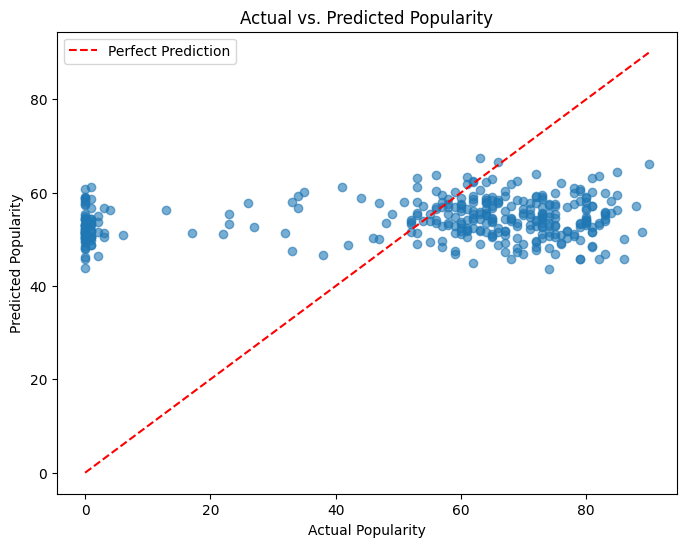

In [125]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', label='Perfect Prediction')
plt.xlabel('Actual Popularity')
plt.ylabel('Predicted Popularity')
plt.title('Actual vs. Predicted Popularity')
plt.legend()
plt.show()

### 🧠 Conclusion

Based on model performance metrics, coefficients, and visual inspection, song popularity cannot be reliably predicted using musical features alone.  
This suggests that popularity is largely driven by external factors beyond acoustic characteristics.


### Model 2: Popularity Prediction Using Lyrical Features
### 🎯 Feature Selection and Train–Test Split

In this experiment, we investigate whether **lyrical characteristics** can be used to predict song popularity.

Lyrical features capture textual properties such as length, vocabulary richness, and repetition, rather than musical structure.


In [126]:
lyrical_features = [
    'clean_word_count',
    'clean_unique_count',
    'lexical_diversity'
]

X = filtered_df[lyrical_features]
y = filtered_df['popularity']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 📏 Baseline Model

A baseline model predicting the mean popularity is used to assess whether lyrical features provide meaningful predictive power.


In [127]:
baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_test)

mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
r2_baseline = r2_score(y_test, y_pred_baseline)

print(f"Baseline MAE: {mae_baseline:.2f}")
print(f"Baseline R2: {r2_baseline:.2f}")


Baseline MAE: 22.93
Baseline R2: -0.00


### 📊 Linear Regression Model (Lyrical Features)

A Linear Regression model is trained to examine whether basic lyrical properties can explain variations in song popularity.


In [128]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")


Mean Absolute Error (MAE): 22.99
Mean Squared Error (MSE): 839.97
R-squared (R2): -0.01


Compared to the baseline model, the improvement remains limited, suggesting that lyrical features alone are not strong predictors of song popularity.


### 🌲 Random Forest Regression (Lyrical Features)

To explore potential non-linear relationships between lyrical features and popularity, a Random Forest Regressor is applied.


In [129]:
# Initialize Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluation metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest MAE: {mae_rf:.2f}")
print(f"Random Forest MSE: {mse_rf:.2f}")
print(f"Random Forest R2: {r2_rf:.2f}")


Random Forest MAE: 24.26
Random Forest MSE: 967.95
Random Forest R2: -0.16


The Random Forest model performs worse than both the baseline and the linear model, indicating that non-linear relationships between basic lyrical features and popularity are minimal.


### 📈 Actual vs. Predicted Popularity (Lyrical Features)

The scatter plot below compares true popularity values with predictions based solely on lyrical features.


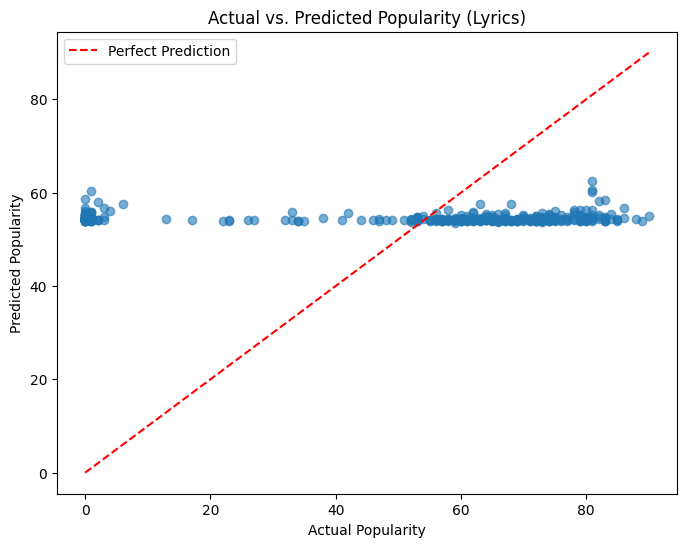

In [130]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    label='Perfect Prediction'
)
plt.xlabel('Actual Popularity')
plt.ylabel('Predicted Popularity')
plt.title('Actual vs. Predicted Popularity (Lyrics)')
plt.legend()
plt.show()


### 🧠 Final Conclusion: Lyrical Features and Popularity

Both linear and non-linear models fail to achieve meaningful predictive performance when using basic lyrical features.  
This suggests that song popularity is not strongly driven by surface-level textual properties such as length or lexical diversity.


### 🔍 Are Simpler and More Repetitive Lyrics Associated with Higher Popularity?

Beyond prediction, we examine whether simpler and more repetitive lyrics are statistically associated with higher song popularity.


In [131]:
corr_wc, p_wc = spearmanr(filtered_df['clean_word_count'], filtered_df['popularity'])
corr_ld, p_ld = spearmanr(filtered_df['lexical_diversity'], filtered_df['popularity'])

print(f"Spearman correlation (Word Count vs Popularity): {corr_wc:.2f} (p={p_wc:.3f})")
print(f"Spearman correlation (Lexical Diversity vs Popularity): {corr_ld:.2f} (p={p_ld:.3f})")


Spearman correlation (Word Count vs Popularity): 0.14 (p=0.000)
Spearman correlation (Lexical Diversity vs Popularity): -0.11 (p=0.000)


Spearman correlation is used due to the non-normal distribution of both lyrical features and popularity scores.

Although the correlations are weak, the consistent negative relationship suggests that simpler lyrics tend to be slightly more popular.



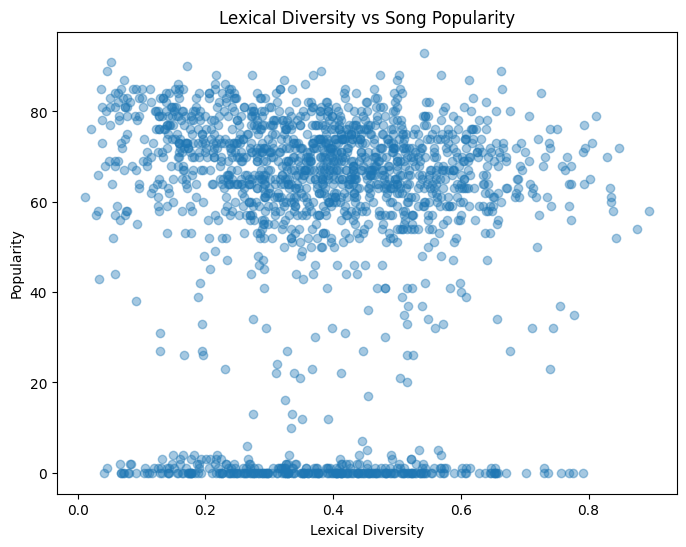

In [132]:
plt.figure(figsize=(8, 6))
plt.scatter(filtered_df['lexical_diversity'], filtered_df['popularity'], alpha=0.4)
plt.xlabel('Lexical Diversity')
plt.ylabel('Popularity')
plt.title('Lexical Diversity vs Song Popularity')
plt.show()


While basic lyrical features fail to predict popularity accurately, simpler and more repetitive lyrics show a weak but consistent association with higher popularity.


### Model 3: Popularity Prediction Using Combined Features
### 🎯 Feature Selection and Train–Test Split

In this experiment, we combine **musical (audio)** and **lyrical** features to evaluate whether a richer feature set improves popularity prediction.


In [133]:
combined_features = [
    # Musical features
    'danceability_x', 'energy_x', 'key_x', 'loudness_x', 'mode_x',
    'speechiness_x', 'acousticness_x', 'instrumentalness_x',
    'liveness_x', 'valence_x', 'tempo_x',

    # Lyrical features
    'clean_word_count', 'clean_unique_count', 'lexical_diversity'
]

X = filtered_df[combined_features]
y = filtered_df['popularity']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


### 📏 Baseline Model

A baseline model predicting the mean popularity is used to provide a reference for evaluating the combined-feature models.


In [134]:
baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_test)

mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
r2_baseline = r2_score(y_test, y_pred_baseline)

print(f"Baseline MAE: {mae_baseline:.2f}")
print(f"Baseline R2: {r2_baseline:.2f}")


Baseline MAE: 22.93
Baseline R2: -0.00


### 📊 Linear Regression Model (Combined Features)

A Linear Regression model is trained to assess whether combining musical and lyrical features improves popularity prediction.


In [135]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")


Mean Absolute Error (MAE): 22.73
Mean Squared Error (MSE): 813.26
R-squared (R2): 0.03


Compared to the baseline, the combined-feature linear model provides only marginal gains.



### 🌲 Random Forest Regression (Combined Features)

A Random Forest model is applied to explore whether non-linear interactions between musical and lyrical features improve prediction performance.


In [136]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest MAE: {mae_rf:.2f}")
print(f"Random Forest MSE: {mse_rf:.2f}")
print(f"Random Forest R2: {r2_rf:.2f}")


Random Forest MAE: 23.11
Random Forest MSE: 840.69
Random Forest R2: -0.01


The Random Forest model does not substantially outperform the linear model, suggesting that complex non-linear interactions offer limited benefit.


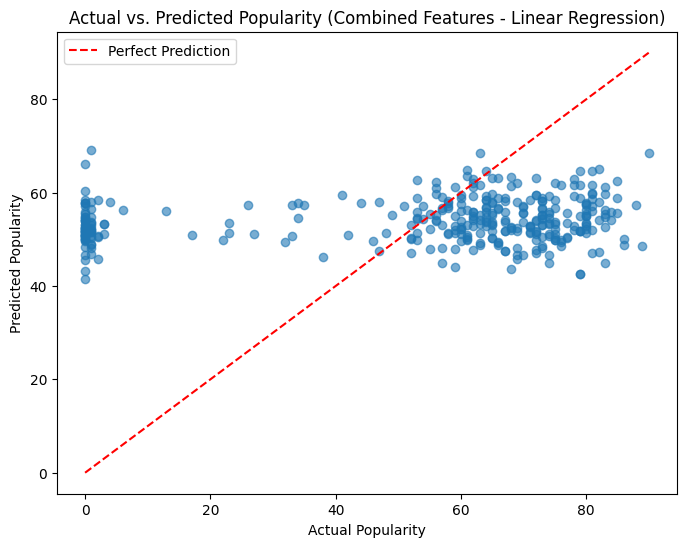

In [137]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    label='Perfect Prediction'
)
plt.xlabel('Actual Popularity')
plt.ylabel('Predicted Popularity')
plt.title('Actual vs. Predicted Popularity (Combined Features - Linear Regression)')
plt.legend()
plt.show()


### 🧠 Conclusion: Popularity Prediction Using Combined Features

Combining musical and lyrical features results in only marginal improvements in predictive performance.  
Both linear and non-linear models achieve low R² scores, indicating that song popularity cannot be reliably predicted even with a richer feature set.

This suggests that popularity is largely driven by external factors beyond audio characteristics and basic lyrical properties.


### Model 4: Valence Prediction Using Lyrical Features
### 🎯 Problem Definition: Valence Prediction from Lyrics

In this experiment, we examine whether a song’s emotional valence (mood) can be predicted using **lyrical features**.
Valence scores are converted into a binary label representing **low** and **high** emotional valence.


In [138]:
# Create binary valence label using median split
valence_median = filtered_df['valence_x'].median()

valence_df = filtered_df.copy()
valence_df['valence_binary'] = valence_df['valence_x'].apply(
    lambda x: 'High Valence' if x >= valence_median else 'Low Valence'
)
valence_df['valence_binary'].value_counts()


,count
valence_binary,
High Valence,860
Low Valence,860


### 🎯 Feature Selection and Train–Test Split

Lyrical features are used as input variables, and binary valence labels are used as the target variable.


In [139]:
lyrical_features = [
    'clean_word_count',
    'clean_unique_count',
    'lexical_diversity'
]

X = valence_df[lyrical_features]
y = valence_df['valence_binary']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


### 📏 Baseline Classifier

A baseline classifier predicting the most frequent valence class is used as a reference.


In [140]:
baseline_clf = DummyClassifier(strategy='most_frequent')
baseline_clf.fit(X_train, y_train)

y_pred_base = baseline_clf.predict(X_test)
acc_base = accuracy_score(y_test, y_pred_base)

print(f"Baseline Accuracy: {acc_base:.2f}")


Baseline Accuracy: 0.50


The baseline accuracy reflects the majority class proportion after the median split.


### 📊 Logistic Regression Classifier

A Logistic Regression model is trained to predict emotional valence using lyrical features.


In [141]:
log_clf = LogisticRegression(max_iter=1000)
log_clf.fit(X_train, y_train)

y_pred_log = log_clf.predict(X_test)

acc_log = accuracy_score(y_test, y_pred_log)
print(f"Logistic Regression Accuracy: {acc_log:.2f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))


Logistic Regression Accuracy: 0.55

Classification Report:
              precision    recall  f1-score   support

High Valence       0.56      0.42      0.48       172
 Low Valence       0.54      0.67      0.60       172

    accuracy                           0.55       344
   macro avg       0.55      0.55      0.54       344
weighted avg       0.55      0.55      0.54       344



### 🌲 Random Forest Classifier

A Random Forest model is applied to explore non-linear relationships between lyrical features and emotional valence.


In [142]:
rf_clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {acc_rf:.2f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.52

Classification Report:
              precision    recall  f1-score   support

High Valence       0.52      0.52      0.52       172
 Low Valence       0.52      0.53      0.53       172

    accuracy                           0.52       344
   macro avg       0.52      0.52      0.52       344
weighted avg       0.52      0.52      0.52       344



The Random Forest model does not substantially outperform Logistic Regression, suggesting that complex non-linear patterns in lyrical features are limited.


### 🧠 Conclusion: Valence Prediction Using Lyrical Features

The results indicate that lyrical features provide modest predictive power for emotional valence.  
While the models outperform the baseline classifier, performance remains limited, suggesting that emotional tone is only partially captured by surface-level textual features.

This aligns with the intuition that musical elements and vocal delivery play a significant role in conveying emotional tone beyond lyrics alone.



### Model 5: High vs. Low Energy Prediction from Lyrics

In this experiment, we investigate whether a song’s **energy level** can be predicted using only **lyrical features**.
Spotify energy scores are converted into binary labels representing **high-energy** and **low-energy** songs.


In [143]:
# Create binary energy label using median split
energy_median = filtered_df['energy_x'].median()

energy_df = filtered_df.copy()
energy_df['energy_binary'] = energy_df['energy_x'].apply(
    lambda x: 'High Energy' if x >= energy_median else 'Low Energy'
)

energy_df['energy_binary'].value_counts()


,count
energy_binary,
High Energy,862
Low Energy,858


### 🎯 Feature Selection and Train–Test Split

Lyrical features are used as input variables, and binary energy labels are used as the target variable.


In [144]:
lyrical_features = [
    'clean_word_count',
    'clean_unique_count',
    'lexical_diversity'
]

X = energy_df[lyrical_features]
y = energy_df['energy_binary']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


### 📏 Baseline Classifier

A baseline classifier predicting the most frequent energy class is used as a reference.


In [145]:
baseline_clf = DummyClassifier(strategy='most_frequent')
baseline_clf.fit(X_train, y_train)

y_pred_base = baseline_clf.predict(X_test)
acc_base = accuracy_score(y_test, y_pred_base)

print(f"Baseline Accuracy: {acc_base:.2f}")


Baseline Accuracy: 0.50


The baseline accuracy reflects the majority class proportion after the median energy split.


### 📊 Logistic Regression Classifier

A Logistic Regression model is trained to predict energy level using lyrical features.


In [146]:
log_clf = LogisticRegression(max_iter=1000)
log_clf.fit(X_train, y_train)

y_pred_log = log_clf.predict(X_test)

acc_log = accuracy_score(y_test, y_pred_log)
print(f"Logistic Regression Accuracy: {acc_log:.2f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))


Logistic Regression Accuracy: 0.56

Classification Report:
              precision    recall  f1-score   support

 High Energy       0.55      0.62      0.58       172
  Low Energy       0.57      0.49      0.53       172

    accuracy                           0.56       344
   macro avg       0.56      0.56      0.56       344
weighted avg       0.56      0.56      0.56       344



### 🌲 Random Forest Classifier

A Random Forest model is applied to explore non-linear relationships between lyrical features and song energy.


In [147]:
rf_clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {acc_rf:.2f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.49

Classification Report:
              precision    recall  f1-score   support

 High Energy       0.49      0.49      0.49       172
  Low Energy       0.49      0.48      0.49       172

    accuracy                           0.49       344
   macro avg       0.49      0.49      0.49       344
weighted avg       0.49      0.49      0.49       344



The Random Forest model does not substantially outperform Logistic Regression, indicating limited non-linear patterns in lyrical features.


### 🧠 Conclusion: High vs. Low Energy Prediction Using Lyrical Features

The results indicate that lyrical features alone provide limited predictive power for distinguishing high-energy and low-energy songs.  
Although the models may slightly outperform the baseline classifier, overall performance remains modest.

This suggests that song energy is primarily driven by musical and production-related factors rather than surface-level lyrical properties.

Together with the valence analysis, this result highlights the limited role of lyrics in conveying musical intensity.



## 🧠 Overall Conclusion

This project investigated the relationship between musical features, lyrical complexity, and song-level outcomes such as popularity, emotional valence, and energy.

The results show that song popularity cannot be reliably predicted using either musical or lyrical features alone, suggesting that external and social factors play a dominant role.  
In contrast, lyrical features exhibit modest predictive power for emotional valence, indicating that lyrics partially convey emotional tone but fail to capture musical intensity.

Overall, the findings highlight the complementary roles of audio and lyrical information in music analysis and emphasize the limitations and strengths of surface-level audio and lyrical representations in music analysis.

